# Measuring badness — how badly do these models fit?

Session 2 pre-class work. The booklet's follow-up questions ask, after critiquing the models:

> **2.** How would you go about measuring how *badly* the **linear** regression model fits the data?
>
> **3.** How would you go about measuring how *badly* the **logistic** regression model fits the data?
>
> **4.** Write some code that implements one of the measures of "badness" you described in the
> question above.

This notebook is the answer to **question 4**, implementing the measures from questions 2 and 3.
Both, not one, because the interesting part is that they have to be different measures — and the
reason why is the answer to question 2.

The model under test is the one from
[`claude-ai-transcript-for-pcw.md`](claude-ai-transcript-for-pcw.md): **sepal length and petal
length**, the same two features, so the numbers here line up with that conversation.

## The argument behind question 2

A single summary number cannot answer "how badly does this fit", because it collapses two separate
questions into one:

- **How much of the variation did the model explain?** That is $R^2$.
- **Is what's left over structureless noise, or is it leftover pattern the model failed to
  capture?** $R^2$ is silent on this. Only a **residual plot** answers it.

That distinction is the whole point. You plot the residual — actual minus fitted — against the
fitted value, and check for curvature, for spread that changes across the range, for outliers, and
for any banding or grouping. A model that fits well leaves a shapeless cloud around zero. Anything
you can *see* in that plot is signal the model left on the table.

For this particular model there is also a third measure available, one that only exists because
the target is categorical: **count the fitted values that are not possible.** The species code only
takes 0, 1 or 2. A fitted value of $-0.31$ is not a wrong species, it is not a species at all.

## The argument behind question 3

Logistic regression needs different tools, for two reasons.

$R^2$ does not apply — it measures variance explained in a *continuous* target, and species is
categorical. And accuracy, the obvious replacement, is one number covering three classes, so it
hides *which* class is failing. A **confusion matrix** with **per-class sensitivity and
specificity** says where the errors actually are.

One further point that matters more than the choice of metric: **no measure computed on training
data can detect overfitting**, whichever one you pick. Training performance rises as a model
memorises, so the number moves in the reassuring direction exactly when things are going wrong.
Everything below is therefore scored by **5-fold cross-validation**, so no flower is ever judged by
a model that has seen it.

R^2 = 0.9090   <- looks good, and that is exactly the problem
fitted values outside the valid label range [0, 2]: 38 of 150  (25%)
fitted range: -0.312 to 2.278
  setosa      residual mean +0.030  sd 0.095
  versicolor  residual mean -0.242  sd 0.180
  virginica   residual mean +0.212  sd 0.191

5-fold cross-validated accuracy = 0.9533

confusion matrix (rows = true species, columns = predicted)
                 setosa  versicolo  virginica
setosa               50          0          0
versicolor            0         46          4
virginica             0          3         47

species       sensitivity  specificity   errors
setosa             1.0000       1.0000        0
versicolor         0.9200       0.9700        4
virginica          0.9400       0.9600        3


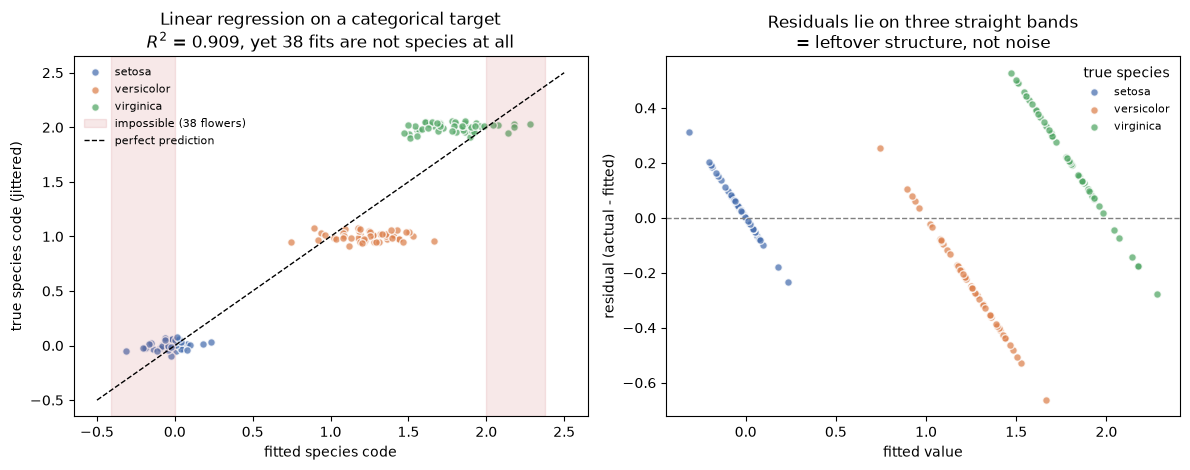

In [1]:
# ============================================================================
# BADNESS MEASURES — how badly does each model fit the Iris data?
#
# Booklet question 4: implement one of the measures of "badness" described for
# questions 2 (linear) and 3 (logistic). Both are implemented here, because the
# right measure is different in each case and the contrast is the point.
#
#   LINEAR  — R^2 says how much variance is explained. It cannot say whether
#             what is left over is structureless noise (which the model assumes)
#             or leftover pattern the model failed to capture. Only a residual
#             plot separates those two, so both are computed.
#   LOGISTIC— accuracy is one number for three classes and hides which class is
#             failing. A confusion matrix with per-class sensitivity and
#             specificity says where the errors actually are, scored by 5-fold
#             cross-validation so no flower is judged by a model that saw it.
#
# Same two features as the conversation this follows: sepal length, petal length.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix, r2_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score

iris = load_iris()
X = iris.data[:, [0, 2]]                 # sepal length, petal length
y = iris.target                          # 0 setosa, 1 versicolor, 2 virginica
names = iris.target_names

# ============================================================================
# PART 1 — BADNESS OF THE LINEAR REGRESSION
# ============================================================================
# Regressing the species CODE (0/1/2) on the measurements. This is the model
# question 2 asks about, and it is already the wrong tool: the codes are nominal
# labels, so treating them as a number asserts that virginica is twice as far
# from setosa as versicolor is. The measures below make that damage visible
# instead of leaving it as an argument.
lin = LinearRegression().fit(X, y)
fitted = lin.predict(X)
residuals = y - fitted

# --- Measure 1: R^2, the summary number ------------------------------------
print(f"R^2 = {r2_score(y, fitted):.4f}"
      f"   <- looks good, and that is exactly the problem")

# --- Measure 2: fitted values that cannot exist ----------------------------
# The target only ever takes 0, 1 or 2. Any fitted value outside [0, 2] is not
# an inaccurate species, it is not a species at all. A regression model has no
# way to know that, so counting these is a badness measure R^2 cannot express.
impossible = (fitted < 0) | (fitted > 2)
print(f"fitted values outside the valid label range [0, 2]: "
      f"{impossible.sum()} of {len(y)}  ({impossible.mean():.0%})")
print(f"fitted range: {fitted.min():.3f} to {fitted.max():.3f}")

# --- Measure 3: the residual plot, which is the real answer ---------------
# A residual is actual minus fitted. If the model is right, residuals scatter
# structurelessly around 0 with constant spread. Here they cannot: because the
# target only takes three values, the residuals are forced onto three straight
# diagonal bands, one per species. That banding IS the diagnosis — it is
# leftover structure, not noise, and no amount of refitting a line removes it.
for k, name in enumerate(names):
    r = residuals[y == k]
    print(f"  {name:<11} residual mean {r.mean():+.3f}  sd {r.std():.3f}")

# ============================================================================
# PART 2 — BADNESS OF THE LOGISTIC REGRESSION
# ============================================================================
# Accuracy on the training rows is not a badness measure at all: the model has
# already seen those labels. Cross-validation predicts each flower using folds
# that excluded it, so every prediction below is genuinely out-of-sample.
cv = StratifiedKFold(n_splits=5)
log = LogisticRegression(max_iter=1000)
y_cv = cross_val_predict(log, X, y, cv=cv)
cv_acc = cross_val_score(log, X, y, cv=cv).mean()

print(f"\n5-fold cross-validated accuracy = {cv_acc:.4f}")
print("\nconfusion matrix (rows = true species, columns = predicted)")
cm = confusion_matrix(y, y_cv)
print(f"{'':<12}" + "".join(f"{n[:9]:>11}" for n in names))
for i, name in enumerate(names):
    print(f"{name:<12}" + "".join(f"{v:>11}" for v in cm[i]))

# --- Per-class sensitivity and specificity --------------------------------
# One accuracy number for three classes hides which class is failing. Split it:
#   sensitivity (recall) = of the true X, what fraction did we catch?
#   specificity          = of everything that is NOT X, what fraction did we
#                          correctly leave alone?
# A class can have perfect specificity while missing most of its own members, so
# the pair says something the single number cannot.
print(f"\n{'species':<12}{'sensitivity':>13}{'specificity':>13}{'errors':>9}")
for k, name in enumerate(names):
    tp = cm[k, k]
    fn = cm[k].sum() - tp                       # true k, called something else
    fp = cm[:, k].sum() - tp                    # called k, actually something else
    tn = cm.sum() - tp - fn - fp
    print(f"{name:<12}{tp/(tp+fn):>13.4f}{tn/(tn+fp):>13.4f}{fn:>9}")

# ============================================================================
# THE PLOT — the residual diagnostic from question 2
# ============================================================================
colors = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}
rng = np.random.default_rng(0)           # jitter only, so the 50 dots per row separate
fig_badness, (ax_fit, ax_res) = plt.subplots(1, 2, figsize=(12, 4.8))

# Left: fitted vs actual, with the impossible zone shaded.
for k, name in enumerate(names):
    ax_fit.scatter(fitted[y == k], y[y == k] + rng.normal(0, .04, (y == k).sum()),
                   c=colors[k], s=30, alpha=.75, edgecolor="white", label=name)
ax_fit.axvspan(fitted.min() - .1, 0, color="#C44E52", alpha=.13)
ax_fit.axvspan(2, fitted.max() + .1, color="#C44E52", alpha=.13,
               label=f"impossible ({impossible.sum()} flowers)")
ax_fit.plot([-.5, 2.5], [-.5, 2.5], "k--", lw=1, label="perfect prediction")
ax_fit.set(xlabel="fitted species code", ylabel="true species code (jittered)",
           title=f"Linear regression on a categorical target\n$R^2$ = {r2_score(y, fitted):.3f}, "
                 f"yet {impossible.sum()} fits are not species at all")
ax_fit.legend(frameon=False, fontsize=8, loc="upper left")

# Right: the residual plot. Structure here means the model is wrong.
for k, name in enumerate(names):
    ax_res.scatter(fitted[y == k], residuals[y == k],
                   c=colors[k], s=30, alpha=.75, edgecolor="white", label=name)
ax_res.axhline(0, color="gray", ls="--", lw=1)
ax_res.set(xlabel="fitted value", ylabel="residual (actual - fitted)",
           title="Residuals lie on three straight bands\n= leftover structure, not noise")
ax_res.legend(frameon=False, fontsize=8, title="true species")

plt.tight_layout()
plt.show()

## Reading the output

### Question 2 — the linear regression is badly fitted, and $R^2$ says the opposite

$R^2 = 0.909$. Taken alone that reads as a good fit. The other two measures say it is not:

- **38 of the 150 fitted values — 25% — fall outside the valid label range $[0, 2]$**, running from
  $-0.312$ to $2.278$. A quarter of this model's outputs are not wrong species; they are not
  species. No regression metric can express that failure, because regression has no concept of a
  value being *inadmissible*.
- **The residual plot is the real verdict.** The residuals do not scatter around zero — they fall on
  **three perfectly straight diagonal bands**, one per species. That is the most structure a
  residual plot can possibly show. Since the target only ever takes three values, the residual is
  forced to equal $k - \hat{y}$ for $k \in \{0,1,2\}$, so each species traces an exact line of slope
  $-1$. No refitting removes it; it is a consequence of using a continuous model on a categorical
  target.
- The **per-species residual means** confirm the bias is systematic, not random: setosa $+0.030$,
  versicolor $\mathbf{-0.242}$, virginica $\mathbf{+0.212}$. The model overshoots versicolor and
  undershoots virginica *as a rule*, which is exactly what "leftover pattern" means.

So the answer to question 2 is: $R^2$ is necessary but not sufficient, and here it is actively
misleading. The residual plot detects the failure that the summary number conceals, and the count
of impossible fits quantifies a kind of wrongness that $R^2$ cannot represent at all.

### Question 3 — the logistic regression fits well, and the breakdown says where it doesn't

**5-fold cross-validated accuracy = 0.9533**, so 7 of 150 flowers are misclassified out of sample.
The per-class breakdown is what accuracy alone hides:

| species | sensitivity | specificity | missed |
|---|---|---|---|
| setosa | **1.0000** | **1.0000** | 0 |
| versicolor | 0.9200 | 0.9700 | 4 |
| virginica | 0.9400 | 0.9600 | 3 |

**Setosa is perfect on both measures** — every setosa caught, and nothing else ever mistaken for
one. All seven errors are versicolor and virginica trading places, and the confusion matrix shows
the trade is nearly symmetric: 4 versicolor called virginica, 3 virginica called versicolor.

That is a genuinely different diagnosis from "95% accurate". The model is not uniformly slightly
wrong; it is **flawless on one class and imperfect on a single boundary**. Reporting one number
would have averaged those two very different behaviours into a figure that describes neither.

### What this says about the two models together

The comparison is the payoff. On the same data and the same two features, the linear model scores
$R^2 = 0.909$ and the logistic model scores 0.953 accuracy — superficially similar-looking numbers.
But the linear model's badness measures reveal a structural failure, while the logistic model's
reveal a narrow, well-understood limitation at one boundary. **How badly a model fits is not a
quantity you can read off a single number; it depends on asking the measure that can see the
failure mode you actually have.**

---

### Repo bookkeeping

The cell below is **not part of the booklet** — it only writes the figure to `assets/` so it
renders in the session README without anyone having to run the notebook.

In [2]:
# Repo only — save the figure produced above for the session README.
fig_badness.savefig("assets/badness-measures.png", dpi=150, bbox_inches="tight")
print("saved 1 figure to assets/")

saved 1 figure to assets/
